# ANN on Fashion-MNIST

In this notebook, we will build and train a simple Artificial Neural Network (ANN)
using PyTorch for image classification on the Fashion-MNIST dataset.

### What we will learn

1. Loading a CSV dataset using Pandas
2. Understanding Fashion-MNIST images
3. Visualizing images
4. Separating features and labels
5. Train-Test Split
6. Feature Scaling / Normalization
7. Creating a Custom Dataset
8. Creating DataLoaders
9. Building an ANN using `nn.Sequential`
10. Understanding `Linear` and `ReLU`
11. Forward Pass
12. Cross Entropy Loss
13. SGD Optimizer
14. Training Loop
15. Backpropagation
16. Updating model parameters
17. Evaluation using Test Data
18. Calculating Classification Accuracy

### Overall Pipeline

```text
Fashion-MNIST CSV
       ↓
     Pandas
       ↓
Features (X) + Labels (y)
       ↓
Train-Test Split
       ↓
Normalization
       ↓
Custom Dataset
       ↓
DataLoader
       ↓
ANN Model
       ↓
Forward Pass
       ↓
Loss Calculation
       ↓
Backpropagation
       ↓
Optimizer
       ↓
Weight Update
       ↓
Evaluation
       ↓
Accuracy

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

#  Setting the Random Seed

We set a random seed to make our results reproducible.

```python
torch.manual_seed(42)

In [10]:
# Set random seeds for reproducibilty
torch.manual_seed(42)

#  Loading the Dataset

We use Pandas to read the Fashion-MNIST CSV file.

### `pd.read_csv()`

`read_csv()` reads a CSV file and converts it into a Pandas DataFrame.

### Syntax

```python
pd.read_csv("file_path")

In [11]:
df = pd.read_csv('/content/fmnist_small.csv')

In [12]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


#  Understanding the Fashion-MNIST Dataset

Fashion-MNIST is an image classification dataset containing grayscale
images of clothing items.

Each image has:

```text
28 × 28 pixels



#  Visualizing the Images

Before training a model, it is useful to visually inspect the data.

We create a:


4 × 4 grid

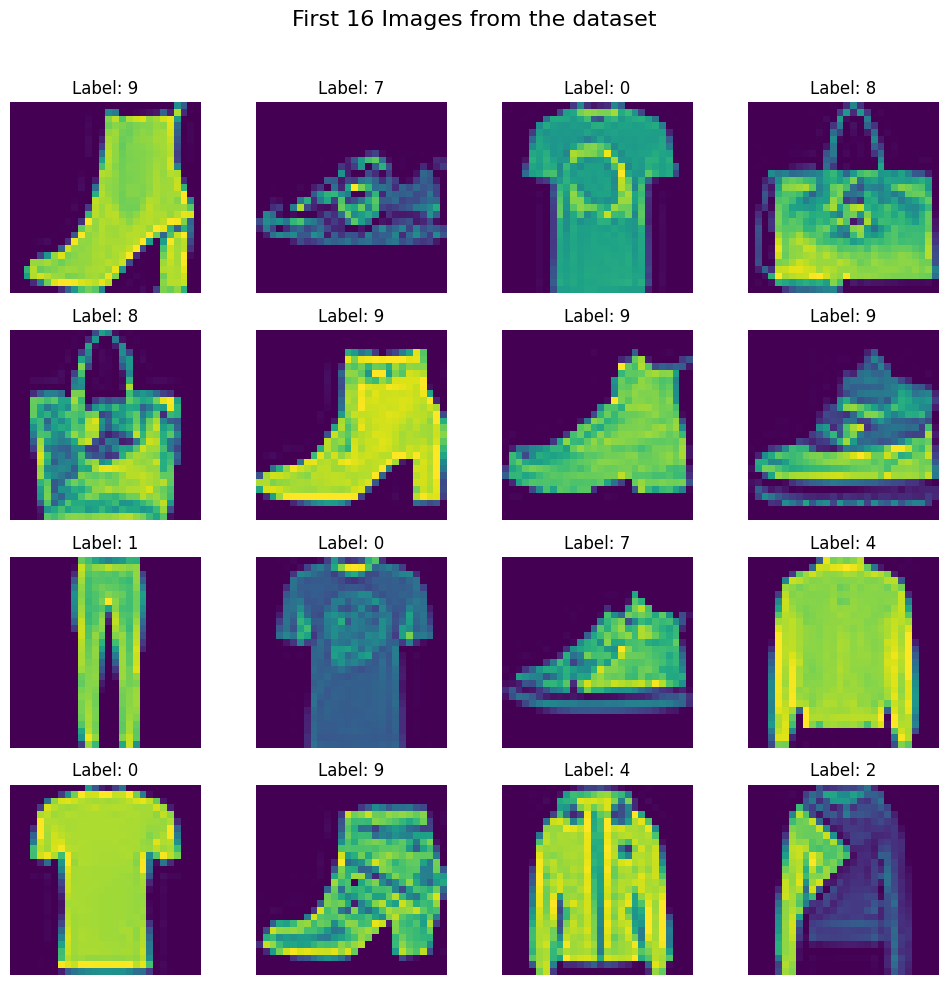

In [13]:
# Create a 4*4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images from the dataset", fontsize=16)

# Plot the first 16 images from the datset
for i, ax in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28,28)     # Reshape to 28 * 28
  ax.imshow(img)                                 # Display in grayscale
  ax.axis('off')                                 # Remove axis for a cleaneer look
  ax.set_title(f"Label: {df.iloc[i, 0]}")        # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])              # Adjust layout tot fit
plt.show()

#  Separating Features and Labels

We separate the dataset into:

```text
X → Input features
y → Target labels

# Train-Test Split

We divide our dataset into two parts:

### Training Data

Used by the model to learn the relationship between:

```text
Input → Output

In [14]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Feature Scaling / Normalization

Originally, each pixel has a value between:

```text
0 and 255

In [16]:
# Scaling the features

X_train = X_train/255.0
X_test = X_test/255.0

In [17]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

#  Creating a Custom Dataset

PyTorch's `Dataset` class provides a standard way to access our data.

Our CustomDataset will:

1. Store the features
2. Store the labels
3. Tell PyTorch how many samples exist
4. Return one sample and its label when requested

We implement three important methods:

```python
__init__()
__len__()
__getitem__()

In [18]:
# Create a CustomDatset Clss
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self, index):

    return self.features[index], self.labels[index]

#  Creating the Training Dataset

We create a Dataset object using:

```python
X_train
y_train

In [19]:
# Create train_dataset object

train_dataset = CustomDataset(X_train, y_train)

In [20]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

# Creating the Test Dataset

We create another Dataset object for the testing data.

It is important to keep the training and testing datasets separate.

```text
Training Dataset
    ↓
Used to learn model parameters

Testing Dataset
    ↓
Used to evaluate the trained model

In [21]:
# Create test_dataset object

test_dataset = CustomDataset(X_test, y_test)

#  Creating DataLoaders

A `DataLoader` takes a Dataset and provides the data in batches.

We create:

```text
train_loader
test_loader

In [22]:
# Create train and test loader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Building the ANN

Now we create our Artificial Neural Network.

We inherit from:

```python
nn.Module



# Understanding `nn.Linear`

`nn.Linear` represents a fully connected / linear layer.

### Syntax

```python
nn.Linear(in_features, out_features)



#  Understanding ReLU

ReLU stands for:

**Rectified Linear Unit**

Its mathematical definition is:


ReLU(x) = max(0, x)

#  Understanding the `forward()` Method

The `forward()` method defines how input data moves through the network.

```python
def forward(self, x):
    return self.model(x)

In [23]:
# Define NN class

class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):

    return self.model(x)



# Setting Epochs and Learning Rate

### Epoch

An epoch means one complete pass through the entire training dataset.

### Learning rate
A larger learning rate can make learning faster, but if it is too large,
training can become unstable.
A smaller learning rate usually produces smaller updates and may require
more training iterations.

In [24]:
# Set Learning rate and epochs

epochs = 100
learning_rate = 0.1

#  Instantiating the Model

We create an object of our `MyNN` class.

```python
model = MyNN(X_train.shape[1])

# Loss Function

We use:

CrossEntropyLoss internally handles the required normalization
operation as part of its calculation

# Optimizer

We use:

SGD :
Stochastic Gradient Descent
The optimizer is responsible for updating the model's learnable parameters
using the gradients calculated during backpropagation.


In [25]:
# Instantiate the model
model = MyNN(X_train.shape[1])

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.SGD(model.parameters(), lr = learning_rate)


In [26]:
len(train_loader)

150

# Training Loop

The training loop is the process through which the model learns from the
training data. It performs a forward pass, calculates the loss, computes
gradients, and updates the model parameters for every batch.

### `model(batch_features)`

**Definition:** Performs the **forward pass** by passing the input batch
through the neural network and generating predictions.

### `criterion(outputs, batch_labels)`

**Definition:** Calculates the **loss** by comparing the model's predictions
with the actual labels.

### `optimizer.zero_grad()`

**Definition:** Clears the gradients from the previous iteration. PyTorch
accumulates gradients by default, so they must be reset before calculating
new gradients.

### `loss.backward()`

**Definition:** Performs **backpropagation** and calculates the gradients of
the loss with respect to the model's learnable parameters.

### `optimizer.step()`

**Definition:** Updates the model's weights and biases using the gradients
calculated during backpropagation.

### `loss.item()`

**Definition:** Converts the loss tensor into a Python numerical value so it
can be used for calculations such as accumulating and averaging the loss.

### `len(train_loader)`

**Definition:** Returns the total number of batches in the training
DataLoader.

### Training Process


Forward Pass
      ↓
Calculate Loss
      ↓
Clear Gradients
      ↓
Backpropagation
      ↓
Update Parameters
      ↓
Next Batch

In [33]:

# Training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # Forward Pass
    outputs = model(batch_features)

    # Calculate loss
    loss = criterion(outputs, batch_labels)

    # Back pass
    optimizer.zero_grad()
    loss.backward()

    # Update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1}, Loss: {avg_loss}')

Epoch: 1, Loss: 0.009086478505826865
Epoch: 2, Loss: 0.020349123581545427
Epoch: 3, Loss: 0.008436801874389251
Epoch: 4, Loss: 0.004241200683172792
Epoch: 5, Loss: 0.003820111741273043
Epoch: 6, Loss: 0.0026870672781175624
Epoch: 7, Loss: 0.0023833862126533254
Epoch: 8, Loss: 0.004788965928116037
Epoch: 9, Loss: 0.002484611928327164
Epoch: 10, Loss: 0.002060313670372125
Epoch: 11, Loss: 0.0017460693924416168
Epoch: 12, Loss: 0.0016626648415694945
Epoch: 13, Loss: 0.0015875323411940674
Epoch: 14, Loss: 0.0014826354771503248
Epoch: 15, Loss: 0.0014517064841735798
Epoch: 16, Loss: 0.0014173426116273428
Epoch: 17, Loss: 0.0013913691649213432
Epoch: 18, Loss: 0.0012670023122336716
Epoch: 19, Loss: 0.0012372740723852378
Epoch: 20, Loss: 0.001202227577547698
Epoch: 21, Loss: 0.0011644989738124423
Epoch: 22, Loss: 0.0011179340343126871
Epoch: 23, Loss: 0.001126764299988281
Epoch: 24, Loss: 0.001063928584723423
Epoch: 25, Loss: 0.0010369510013454905
Epoch: 26, Loss: 0.0010319371228009308
Epoch:

In [34]:
# Set model to eval mode

model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [37]:
# Evaluation code

total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

  print(correct/total)

0.8375


In [36]:
len(test_loader)

38

#  Complete ANN Training Pipeline

The complete workflow implemented in this notebook is:

```text
                 Fashion-MNIST
                       ↓
                  Read CSV
                       ↓
                  Visualize
                       ↓
              Separate X and y
                       ↓
                Train-Test Split
                       ↓
                  Normalize
                       ↓
              CustomDataset
                  ↙       ↘
            Train Set    Test Set
                ↓            ↓
          TrainLoader    TestLoader
                ↓
             ANN Model
                ↓
          Forward Pass
                ↓
         CrossEntropyLoss
                ↓
         optimizer.zero_grad()
                ↓
           loss.backward()
                ↓
          optimizer.step()
                ↓
             Repeat
                ↓
            model.eval()
                ↓
          Test DataLoader
                ↓
             Predictions
                ↓
             Accuracy





#  Important Definitions — Quick Revision

### Fashion-MNIST
A dataset of 28×28 grayscale images belonging to 10 clothing-related
classes.

### Feature
An input value used by the model. Here, each pixel is a feature.

### Label
The correct class associated with an image.

### Normalization
Scaling input values to a smaller numerical range. Here, pixel values
are divided by 255.

### Dataset
Provides access to individual samples and labels.

### DataLoader
Loads samples from a Dataset in batches.

### Batch
A group of samples processed together.

### ANN
Artificial Neural Network consisting of interconnected layers of neurons.

### Linear Layer
A fully connected layer that performs a weighted linear transformation.

### ReLU
An activation function defined as:


ReLU(x) = max(0, x)